In [74]:
import pandas as pd
import os

In [75]:
# Define the directory containing CSV files
csv_dir = '../result/test/sctab/zeinab-classification-evals-20250409-manuscript-version/'

# Define expected columns
columns = ['accuracy', 'precision', 'recall', 'micro_f1', 'macro_f1', 'seed', 'dataset', 'ARtype', 'latent_dim', 'Atlas_cell_count']

# Initialize an empty list to store DataFrames
df_list = []

# Loop over all CSV files in the directory
for file in os.listdir(csv_dir):
    if file.endswith(".csv"):
        file_path = os.path.join(csv_dir, file)
        df_temp = pd.read_csv(file_path, usecols=columns)  # Load only relevant columns
        df_temp["Balancing_method"] = 'Original combination'
        df_list.append(df_temp)  # Store DataFrame in the list

# Concatenate all DataFrames into one
df_original = pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame(columns=columns)


In [76]:
df_original.shape

(210, 11)

In [77]:
# Define the directory containing CSV files
csv_dir = '../result/test/sctab/scVI-classification-evals-balanced-data/'

# Initialize an empty list to store DataFrames
df_list = []

# Loop over all CSV files in the directory
for file in os.listdir(csv_dir):
    if file.endswith(".csv"):
        balancing_method = None
        if "class_balancing" in file:
            balancing_method = "class_balancing"
        elif "geometric_sketching" in file:
            balancing_method = "geometric_sketching"
        else:
            continue
        file_path = os.path.join(csv_dir, file)
        df_temp = pd.read_csv(file_path, usecols=columns)  # Load only relevant columns
        df_temp["Balancing_method"] = balancing_method
        df_list.append(df_temp)  # Store DataFrame in the list

df_balanced = pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame(columns=columns)


In [78]:
print(df_balanced.shape)
print(df_balanced[df_balanced['seed'] == 42].shape[0])
print(df_balanced[df_balanced['seed'] == 43].shape[0])
print(df_balanced[df_balanced['seed'] == 44].shape[0])
print(df_balanced[df_balanced['seed'] == 45].shape[0])
print(df_balanced[df_balanced['seed'] == 46].shape[0])
# check if the number of rows for each seed is the same
# assert df_balanced[df_balanced['seed'] == 42].shape[0] \
#     == df_balanced[df_balanced['seed'] == 43].shape[0] \
#     == df_balanced[df_balanced['seed'] == 44].shape[0] \
#     == df_balanced[df_balanced['seed'] == 45].shape[0] \
#     == df_balanced[df_balanced['seed'] == 46].shape[0]


(210, 11)
42
42
42
42
42


In [79]:
df_42 = df_balanced[df_balanced['seed'] == 42]
# sort df_42 based on Atlas_cell_count, Balancing_method 
df_42 = df_42.sort_values(by=['Atlas_cell_count', 'Balancing_method'])
df_42

,accuracy,precision,recall,micro_f1,macro_f1,seed,dataset,ARtype,latent_dim,Atlas_cell_count,Balancing_method
55,0.685640,0.647790,0.546305,0.685640,0.565179,42,Kidney,F,64,0,class_balancing
133,0.579000,0.564365,0.458131,0.579000,0.482723,42,Neurons,F,64,0,class_balancing
166,0.727822,0.680955,0.505295,0.727822,0.542871,42,Heart,F,64,0,class_balancing
22,0.595800,0.550550,0.465577,0.595800,0.484576,42,Neurons,F,64,0,geometric_sketching
115,0.662494,0.649083,0.512378,0.662494,0.546741,42,Kidney,F,64,0,geometric_sketching
138,0.725612,0.615374,0.483300,0.725612,0.512506,42,Heart,F,64,0,geometric_sketching
18,0.530200,0.562677,0.448356,0.530200,0.469827,42,Neurons,F,64,1,class_balancing
106,0.717801,0.597435,0.461643,0.717801,0.489918,42,Heart,F,64,1,class_balancing
119,0.623996,0.580410,0.463519,0.623996,0.489560,42,Kidney,F,64,1,class_balancing
41,0.554200,0.486731,0.429517,0.554200,0.440629,42,Neurons,F,64,1,geometric_sketching


In [80]:
df_43 = df_balanced[df_balanced['seed'] == 43]
# sort df_42 based on Atlas_cell_count, Balancing_method 
df_43 = df_43.sort_values(by=['Atlas_cell_count', 'Balancing_method'])
df_43



,accuracy,precision,recall,micro_f1,macro_f1,seed,dataset,ARtype,latent_dim,Atlas_cell_count,Balancing_method
12,0.716180,0.656842,0.449520,0.716180,0.478345,43,Heart,F,64,0,class_balancing
81,0.570800,0.573796,0.459787,0.570800,0.476613,43,Neurons,F,64,0,class_balancing
208,0.670997,0.619170,0.517159,0.670997,0.542008,43,Kidney,F,64,0,class_balancing
60,0.665801,0.628899,0.511857,0.665801,0.537592,43,Kidney,F,64,0,geometric_sketching
85,0.696876,0.623557,0.461688,0.696876,0.498883,43,Heart,F,64,0,geometric_sketching
175,0.559400,0.504124,0.438952,0.559400,0.456699,43,Neurons,F,64,0,geometric_sketching
69,0.661313,0.604762,0.493094,0.661313,0.521648,43,Kidney,F,64,1,class_balancing
155,0.707044,0.571551,0.458283,0.707044,0.486189,43,Heart,F,64,1,class_balancing
170,0.532400,0.630566,0.455387,0.532400,0.490876,43,Neurons,F,64,1,class_balancing
68,0.711170,0.684509,0.483361,0.711170,0.511993,43,Heart,F,64,1,geometric_sketching


In [81]:
# concat df_balanced and df_original
df = pd.concat([df_balanced, df_original])
df.head()

,accuracy,precision,recall,micro_f1,macro_f1,seed,dataset,ARtype,latent_dim,Atlas_cell_count,Balancing_method
0,0.643599,0.597501,0.490269,0.643599,0.517724,44,Kidney,F,64,1,geometric_sketching
1,0.837600,0.855769,0.752424,0.837600,0.783970,43,Neurons,F,64,100,class_balancing
2,0.687200,0.685560,0.562636,0.687200,0.584253,42,Neurons,F,64,50000,geometric_sketching
3,0.672650,0.603847,0.506189,0.672650,0.525571,43,Kidney,F,64,10,class_balancing
4,0.649268,0.583255,0.477542,0.649268,0.497896,44,Kidney,F,64,1,class_balancing


In [82]:
# print number of rows for each Balancing_method
print(df['Balancing_method'].value_counts())


Balancing_method
Original combination    210
geometric_sketching     105
class_balancing         105
Name: count, dtype: int64


In [83]:
# remove repeted rows
df = df.drop_duplicates()
df.head()

,accuracy,precision,recall,micro_f1,macro_f1,seed,dataset,ARtype,latent_dim,Atlas_cell_count,Balancing_method
0,0.643599,0.597501,0.490269,0.643599,0.517724,44,Kidney,F,64,1,geometric_sketching
1,0.837600,0.855769,0.752424,0.837600,0.783970,43,Neurons,F,64,100,class_balancing
2,0.687200,0.685560,0.562636,0.687200,0.584253,42,Neurons,F,64,50000,geometric_sketching
3,0.672650,0.603847,0.506189,0.672650,0.525571,43,Kidney,F,64,10,class_balancing
4,0.649268,0.583255,0.477542,0.649268,0.497896,44,Kidney,F,64,1,class_balancing


In [84]:
# convert Balancing_method to Class balancing and Geometric sketching
df['Balancing_method'] = df['Balancing_method'].apply(lambda x: 'Class balancing' if x == 'class_balancing' else x)
df['Balancing_method'] = df['Balancing_method'].apply(lambda x: 'Geometric sketching' if x == 'geometric_sketching' else x)


In [85]:
# assert if the number of rows for each seed is the same
# assert df[df['seed'] == '42'].shape[0] \
#     == df[df['seed'] == '43'].shape[0] \
#     == df[df['seed'] == '44'].shape[0] \
#     == df[df['seed'] == '45'].shape[0] \
#     == df[df['seed'] == '46'].shape[0] 

In [86]:
df.columns = ['Accuracy', 'Precision', 'Recall', 'Micro F1 Score', 'Macro F1 Score', 'deed', 'dataset', 'ARtype', 'latent_dim', 'Atlas_cell_count', 'Balancing_method']

In [87]:
import pandas as pd

# Define metrics and target columns
metrics = ['Accuracy', 'Precision', 'Recall', 'Micro F1 Score', 'Macro F1 Score']
columns = ['dataset', 'metric', 'value', 'ARtype', 'Atlas_cell_count', 'Balancing_method']
plot_df_list = []

# Loop through each row in df
for index, row in df.iterrows():
    for metric in metrics:
        tmp_df = pd.DataFrame([[row['dataset'], metric, row[metric], row['ARtype'], row['Atlas_cell_count'], row['Balancing_method']]], 
                              columns=columns)
        plot_df_list.append(tmp_df)

# Concatenate all DataFrames
plot_df = pd.concat(plot_df_list, ignore_index=True) if plot_df_list else pd.DataFrame(columns=columns)


In [88]:
plot_df = plot_df.sort_values(by='Atlas_cell_count')
plot_df.head()

,dataset,metric,value,ARtype,Atlas_cell_count,Balancing_method
183,Neurons,Micro F1 Score,0.549400,F,0,Class balancing
210,Kidney,Accuracy,0.644544,F,0,Class balancing
755,Neurons,Accuracy,0.537400,F,0,Geometric sketching
1450,Kidney,Accuracy,0.623760,F,0,Original combination
1451,Kidney,Precision,0.591754,F,0,Original combination


In [89]:
# change ARtype to AR and Naive
plot_df['ARtype'] = plot_df['ARtype'].replace({'T': 'AR', 'F': 'Standard'})

In [90]:
# print type of each column
print(plot_df.dtypes)
# print the unique values of each column
print(plot_df['dataset'].unique())
print(plot_df['metric'].unique())
print(plot_df['ARtype'].unique())
print(plot_df['Atlas_cell_count'].unique())

dataset              object
metric               object
value               float64
ARtype               object
Atlas_cell_count      int64
Balancing_method     object
dtype: object
['Neurons' 'Kidney' 'Heart']
['Micro F1 Score' 'Accuracy' 'Precision' 'Recall' 'Macro F1 Score']
['Standard' 'AR']
[    0     1    10   100  1000 10000 50000]


In [91]:
# convert object data type to string
plot_df['dataset'] = plot_df['dataset'].astype(str)
plot_df['metric'] = plot_df['metric'].astype(str)
plot_df['ARtype'] = plot_df['ARtype'].astype(str)
plot_df['Balancing_method'] = plot_df['Balancing_method'].astype(str)

In [92]:
# write a piece of code that for each dataset, metric and Atlas_cell_count, it calculated the p-value between AR and Naive using t-test
from scipy import stats
results = []
for dataset in plot_df['dataset'].unique():
    for metric in plot_df['metric'].unique():
        for atlas_cell_count in plot_df['Atlas_cell_count'].unique():
            ar_values = plot_df[(plot_df['dataset'] == dataset) & 
                                (plot_df['metric'] == metric) & 
                                (plot_df['Atlas_cell_count'] == atlas_cell_count) & 
                                (plot_df['ARtype'] == 'AR') &
                                (plot_df['Balancing_method'] == 'Original combination')]['value']
            naive_values = plot_df[(plot_df['dataset'] == dataset) & 
                                   (plot_df['metric'] == metric) & 
                                   (plot_df['Atlas_cell_count'] == atlas_cell_count) & 
                                   (plot_df['ARtype'] == 'Standard') &
                                   (plot_df['Balancing_method'] == 'Original combination')]['value']
            if len(ar_values) > 1 and len(naive_values) > 1:
                t_stat, p_value = stats.ttest_ind(ar_values, naive_values)
                results.append([dataset, metric, atlas_cell_count, p_value])
            else:
                results.append([dataset, metric, atlas_cell_count, None])

In [93]:
results

[['Neurons', 'Micro F1 Score', 0, 0.00877249660297655],
 ['Neurons', 'Micro F1 Score', 1, 0.017972984125250828],
 ['Neurons', 'Micro F1 Score', 10, 0.09060399193258123],
 ['Neurons', 'Micro F1 Score', 100, 0.00013331849905281605],
 ['Neurons', 'Micro F1 Score', 1000, 1.9076343843530267e-07],
 ['Neurons', 'Micro F1 Score', 10000, 9.524849486074098e-07],
 ['Neurons', 'Micro F1 Score', 50000, 0.16196004449918802],
 ['Neurons', 'Accuracy', 0, 0.00877249660297655],
 ['Neurons', 'Accuracy', 1, 0.017972984125250828],
 ['Neurons', 'Accuracy', 10, 0.09060399193258123],
 ['Neurons', 'Accuracy', 100, 0.00013331849905281605],
 ['Neurons', 'Accuracy', 1000, 1.90763438435302e-07],
 ['Neurons', 'Accuracy', 10000, 9.524849486074049e-07],
 ['Neurons', 'Accuracy', 50000, 0.1619600444991913],
 ['Neurons', 'Precision', 0, 0.07974511224264476],
 ['Neurons', 'Precision', 1, 0.034566226020540325],
 ['Neurons', 'Precision', 10, 0.12052855842867131],
 ['Neurons', 'Precision', 100, 0.00010116200348757085],
 ['N

In [94]:
results

[['Neurons', 'Micro F1 Score', 0, 0.00877249660297655],
 ['Neurons', 'Micro F1 Score', 1, 0.017972984125250828],
 ['Neurons', 'Micro F1 Score', 10, 0.09060399193258123],
 ['Neurons', 'Micro F1 Score', 100, 0.00013331849905281605],
 ['Neurons', 'Micro F1 Score', 1000, 1.9076343843530267e-07],
 ['Neurons', 'Micro F1 Score', 10000, 9.524849486074098e-07],
 ['Neurons', 'Micro F1 Score', 50000, 0.16196004449918802],
 ['Neurons', 'Accuracy', 0, 0.00877249660297655],
 ['Neurons', 'Accuracy', 1, 0.017972984125250828],
 ['Neurons', 'Accuracy', 10, 0.09060399193258123],
 ['Neurons', 'Accuracy', 100, 0.00013331849905281605],
 ['Neurons', 'Accuracy', 1000, 1.90763438435302e-07],
 ['Neurons', 'Accuracy', 10000, 9.524849486074049e-07],
 ['Neurons', 'Accuracy', 50000, 0.1619600444991913],
 ['Neurons', 'Precision', 0, 0.07974511224264476],
 ['Neurons', 'Precision', 1, 0.034566226020540325],
 ['Neurons', 'Precision', 10, 0.12052855842867131],
 ['Neurons', 'Precision', 100, 0.00010116200348757085],
 ['N

In [95]:
# Create a DataFrame from the results
pval_df = pd.DataFrame(results, columns=['dataset', 'metric', 'Atlas_cell_count', 'p_value'])

# print the pval_df in the form of a latex table in scientific notation with 2 decimal points, separately for each dataset, with rows as metrics and columns as Atlas_cell_count, with dataseet in caption, colored by their p-value (green for p<0.05, yellow for p>=0.05)
for dataset in pval_df['dataset'].unique():
    subset = pval_df[pval_df['dataset'] == dataset]
    pivot_table = subset.pivot(index='metric', columns='Atlas_cell_count', values='p_value')
    def color_pval(val):
        if pd.isna(val):
            return ''
        elif val < 0.05:
            return 'background-color: green; color: white;'
        else:
            return 'background-color: yellow; color: black;'
    styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")
    # latex_table = styled_table.to_latex(caption=f'P-values for {dataset}', label=f'tab:pvalues_{dataset}')
    # print(latex_table)

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/1670325654.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")
/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/1670325654.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")
/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/1670325654.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")


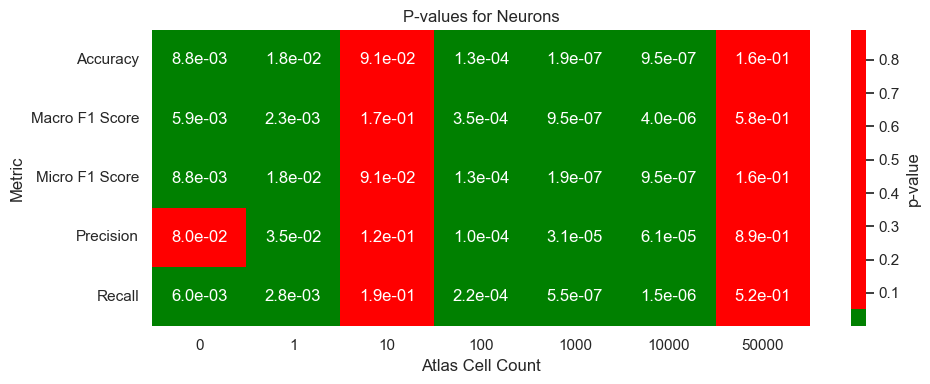

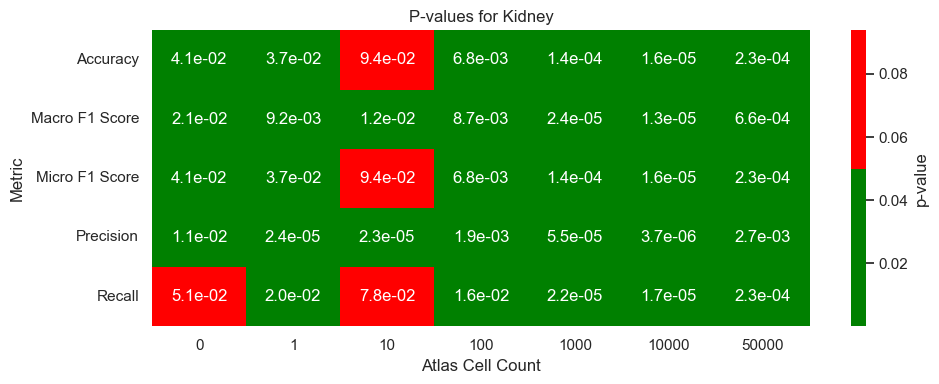

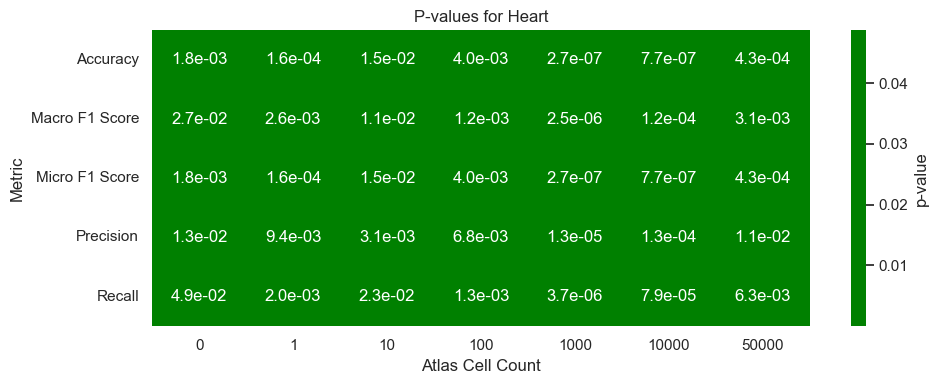

In [96]:
# convert results to a dataframe
results_df = pd.DataFrame(results)
results_df.columns = ['dataset', 'metric', 'Atlas_cell_count', 'p_value']

# plot results_df as a heatmap using seaborn for each dataset separately, with metric on the y-axis, Atlas_cell_count on the x-axis, and p-value < 0.05 light green and >= 0.05 light red, with annotated p-values in scientific notation
import seaborn as sns
import matplotlib.pyplot as plt

for dataset in results_df['dataset'].unique():
    pivot_df = results_df[results_df['dataset'] == dataset].pivot(index='metric', columns='Atlas_cell_count', values='p_value')
    plt.figure(figsize=(10, 4))
    sns.heatmap(pivot_df, annot=True, fmt=".1e", cmap=sns.color_palette(["green", "red"]), center=0.05, cbar_kws={'label': 'p-value'})
    plt.title(f'P-values for {dataset}')
    plt.ylabel('Metric')
    plt.xlabel('Atlas Cell Count')
    plt.tight_layout()
    plt.show()

In [97]:
# print number of rows for each Balancing_method
print(plot_df['Balancing_method'].value_counts())


Balancing_method
Original combination    1050
Class balancing          525
Geometric sketching      525
Name: count, dtype: int64


In [98]:
# change column name Balancing_method to Balancing method
plot_df.rename(columns={'Balancing_method': 'Balancing method'}, inplace=True)
# change column name ARtype to Model
plot_df.rename(columns={'ARtype': 'Model'}, inplace=True)
plot_df.head()


,dataset,metric,value,Model,Atlas_cell_count,Balancing method
183,Neurons,Micro F1 Score,0.549400,Standard,0,Class balancing
210,Kidney,Accuracy,0.644544,Standard,0,Class balancing
755,Neurons,Accuracy,0.537400,Standard,0,Geometric sketching
1450,Kidney,Accuracy,0.623760,Standard,0,Original combination
1451,Kidney,Precision,0.591754,Standard,0,Original combination


/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


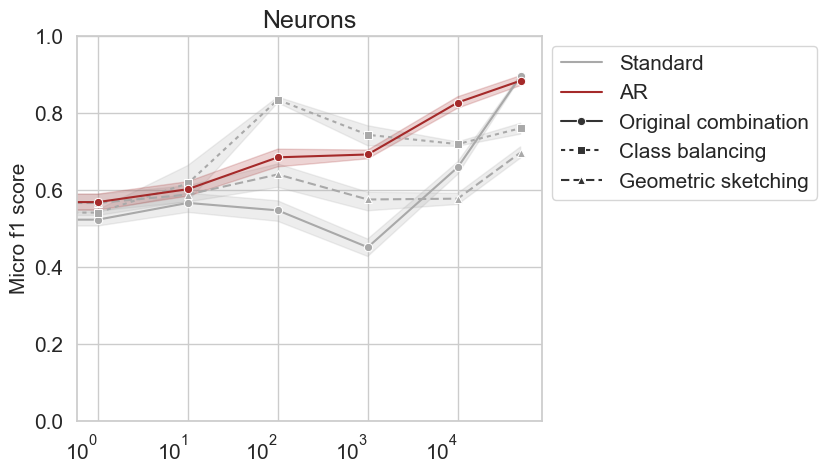

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


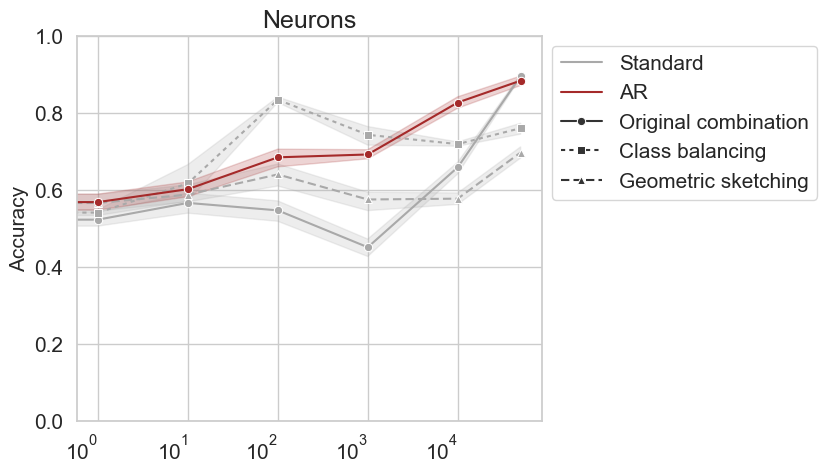

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


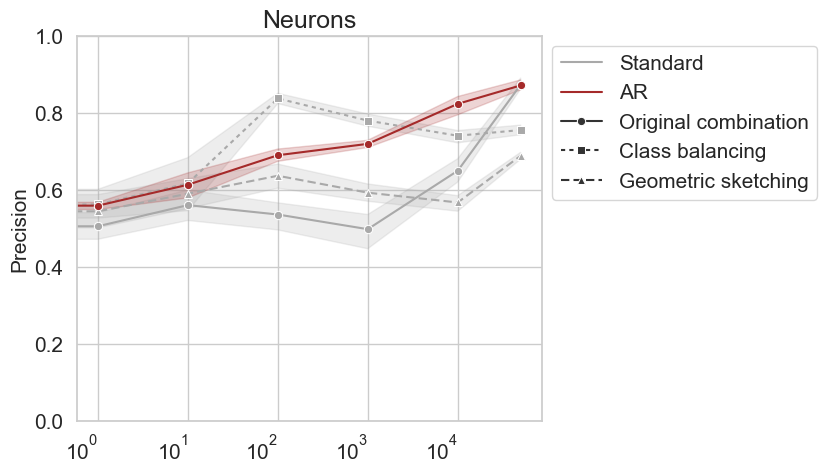

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


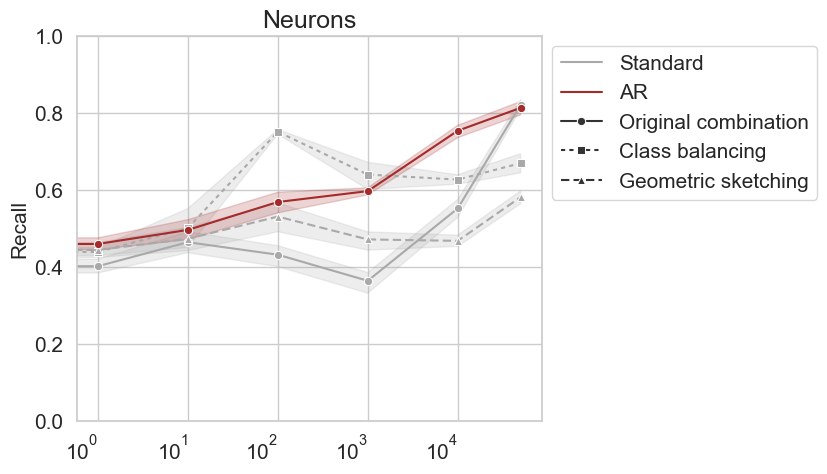

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


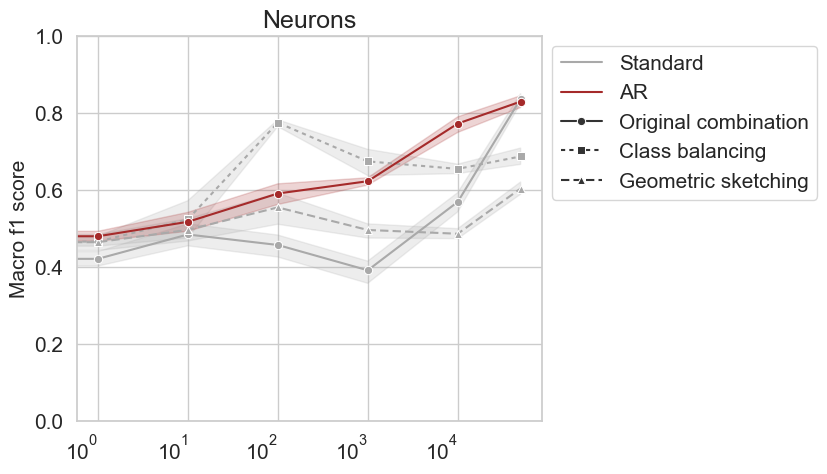

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


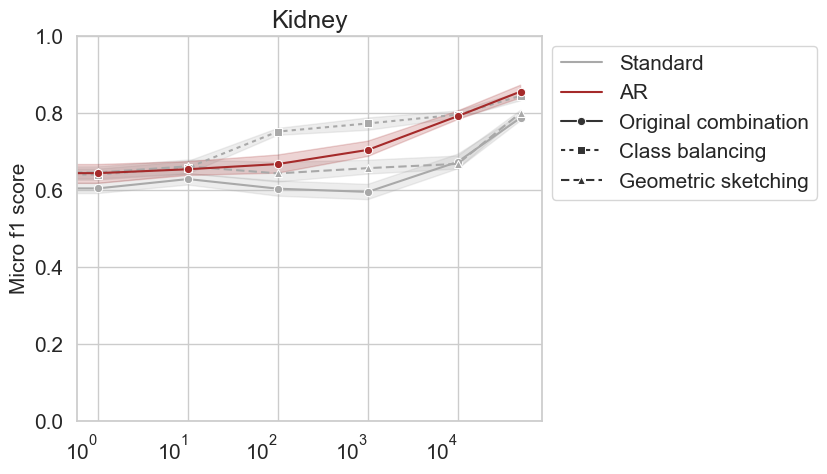

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


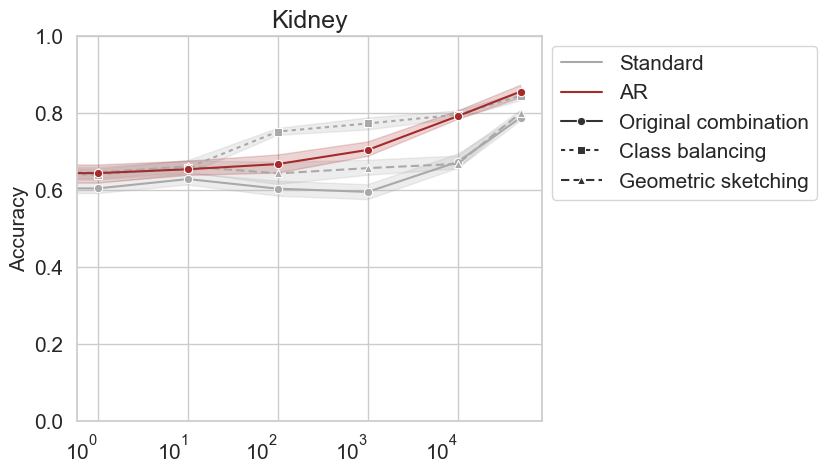

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


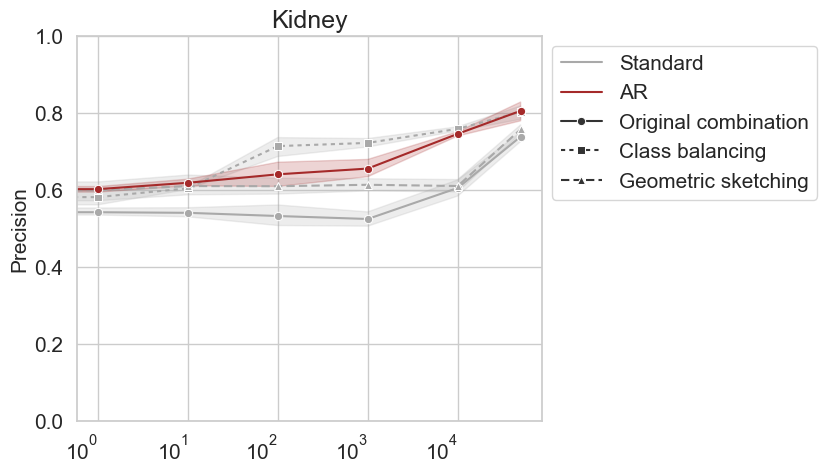

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


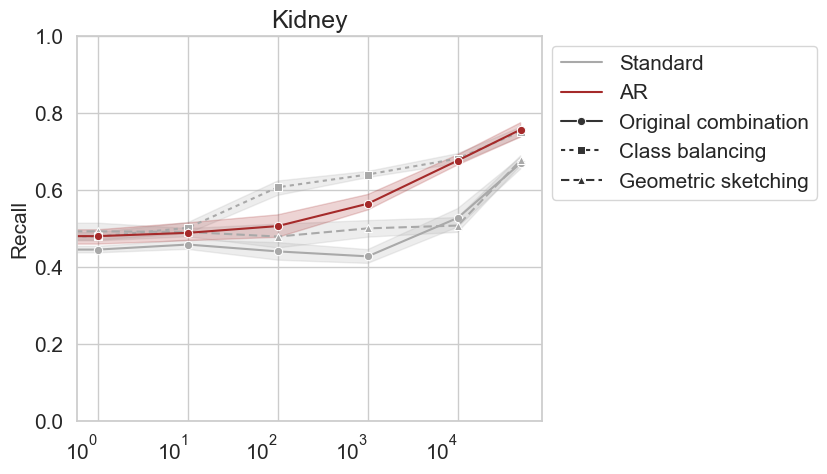

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


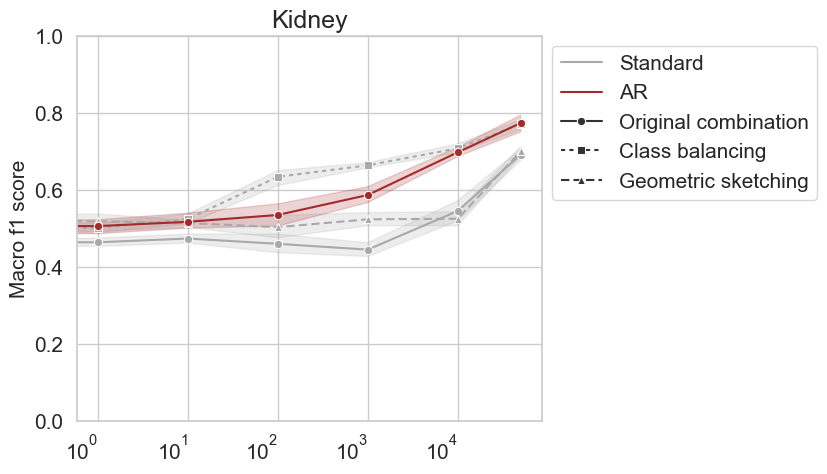

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


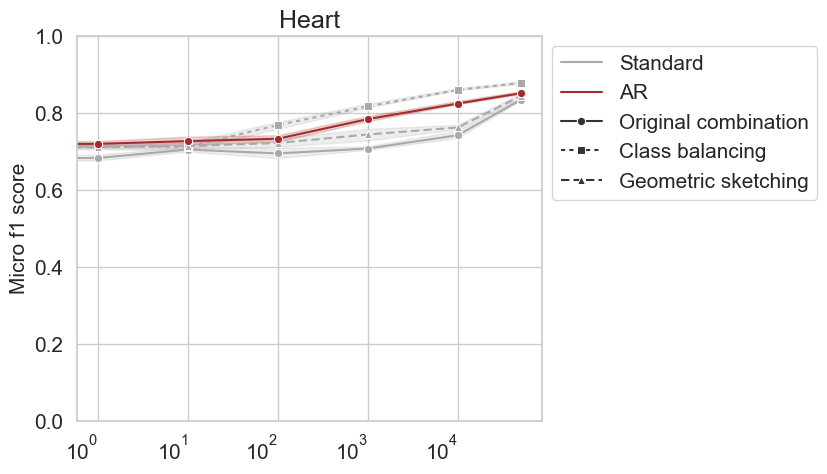

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


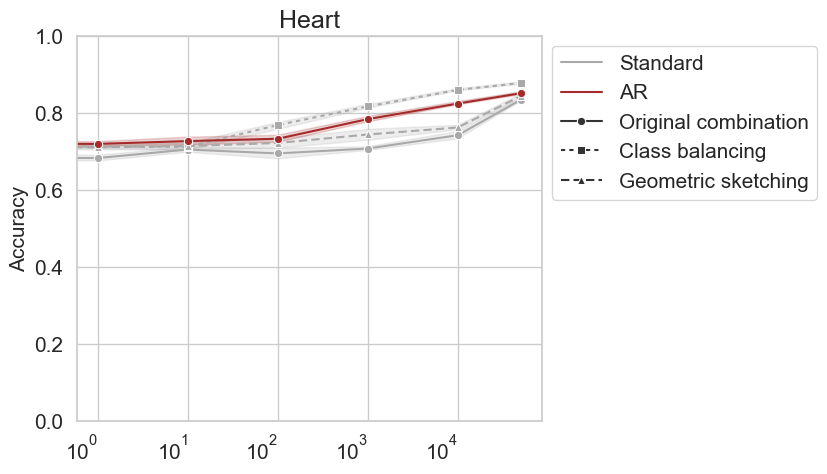

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


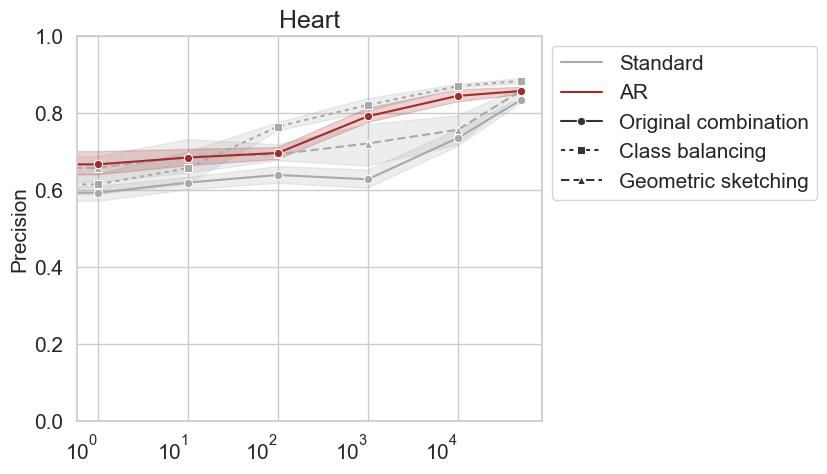

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


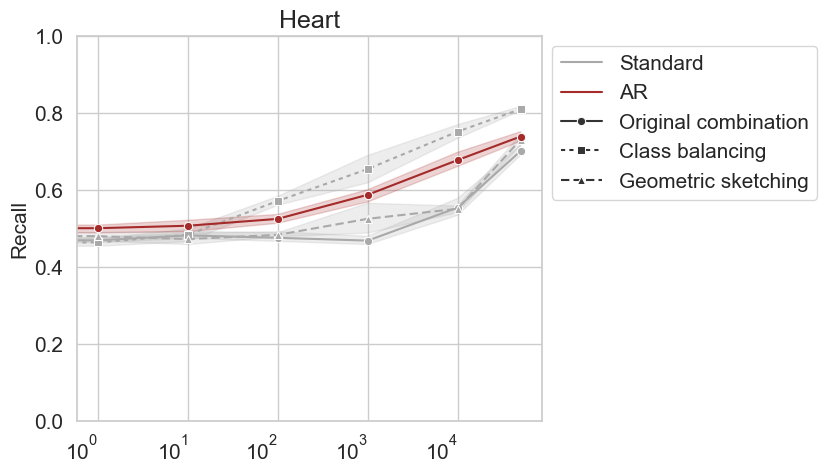

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/964979272.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


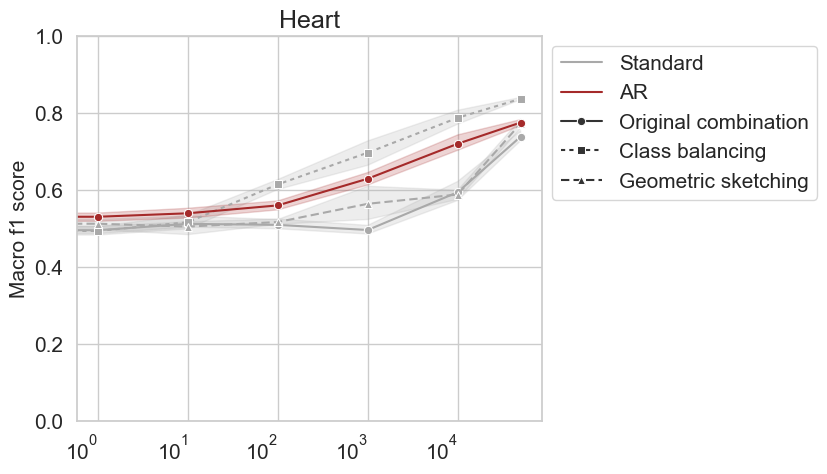

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt
# plot a group barplot for each dataset with metric in x-axis and value in y-axis, hue=AR_Type
palette = {'Standard':"darkgray",
           'AR':"brown"}

balancing_order = [
    'Original combination',
    'Class balancing',
    'Geometric sketching'
]

markers = {
    'Original combination': 'o',
    'Class balancing': 's',
    'Geometric sketching': '^'
}

dashes = {
    'Original combination': '',
    'Class balancing': (2, 2),
    'Geometric sketching': (4, 2)
}

for dataset in plot_df['dataset'].unique():
    # loop through each metric
    for metric in plot_df['metric'].unique():
        fig, axs = plt.subplots(1, 1, figsize=(6, 5))
        sns.set_theme(style="whitegrid")
        # Use hue to differentiate ARtype and style to differentiate alpha values with different colors and line styles
        g = sns.lineplot(
            data=plot_df[(plot_df['dataset'] == dataset) & (plot_df['metric'] == metric)],
            x="Atlas_cell_count",
            y="value",
            hue="Model",
            style="Balancing method",
            hue_order=['Standard', 'AR'],
            style_order=balancing_order,      # ✅ fixes assignment order
            markers=markers,                  # ✅ fixes marker shape
            dashes=dashes,                    # ✅ fixes line style
            palette=palette
        )
        # set x and y labels
        g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')
        g.set_xlabel('')
        g.set_ylabel(metric.capitalize(), fontsize=15)
        g.set_title(dataset.capitalize(), fontsize=18)
        g.tick_params(axis='both', which='major', labelsize=15)
        g.tick_params(axis='both', which='minor', labelsize=15)
        g.set_xscale("log", base=10)
        g.legend(loc='upper left', fontsize=15, bbox_to_anchor=(1, 1))
        # sort the legend in Balancing_method order: Original combination, class_balancing, geometric_sketching
        # sort the legend in Balancing_method order
        desired_order = [
            'Original combination',
            'Class balancing',
            'Geometric sketching'
        ]

        handles, labels = g.get_legend_handles_labels()

        # keep non-style entries (e.g., ARtype) in place
        ordered_handles = []
        ordered_labels = []

        # first add ARtype entries
        for h, l in zip(handles, labels):
            if l in ['Standard', 'AR']:
                ordered_handles.append(h)
                ordered_labels.append(l)

        # then add Balancing_method entries in the desired order
        for method in desired_order:
            for h, l in zip(handles, labels):
                if l == method:
                    ordered_handles.append(h)
                    ordered_labels.append(l)

        g.legend(
            ordered_handles,
            ordered_labels,
            loc='upper left',
            fontsize=15,
            bbox_to_anchor=(1, 1)
        )
        g.set(ylim=(0,1))
        
        # save the plot with high resolution
        plt.savefig(f'/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/new_results/scvi/figure/balanced_data/{dataset}_{metric}.png', dpi=600,
                    bbox_inches='tight')
        plt.show()


compute p-value between AR and class balancing

In [100]:
plot_df

,dataset,metric,value,Model,Atlas_cell_count,Balancing method
183,Neurons,Micro F1 Score,0.549400,Standard,0,Class balancing
210,Kidney,Accuracy,0.644544,Standard,0,Class balancing
755,Neurons,Accuracy,0.537400,Standard,0,Geometric sketching
1450,Kidney,Accuracy,0.623760,Standard,0,Original combination
1451,Kidney,Precision,0.591754,Standard,0,Original combination
...,...,...,...,...,...,...
1816,Kidney,Precision,0.751115,Standard,50000,Original combination
1815,Kidney,Accuracy,0.781530,Standard,50000,Original combination
1814,Kidney,Macro F1 Score,0.787687,AR,50000,Original combination
1822,Heart,Recall,0.727139,Standard,50000,Original combination


In [101]:
# write a piece of code that for each dataset, metric and Atlas_cell_count, it calculated the p-value between AR and class balancing using t-test
from scipy import stats
results_class_balancing = pd.DataFrame(columns=['dataset', 'metric', 'Atlas_cell_count', 'p_value', 'better_method'])

for dataset in plot_df['dataset'].unique():
    for metric in plot_df['metric'].unique():
        for atlas_cell_count in plot_df['Atlas_cell_count'].unique():
            ar_values = plot_df[(plot_df['dataset'] == dataset) & 
                                (plot_df['metric'] == metric) & 
                                (plot_df['Atlas_cell_count'] == atlas_cell_count) & 
                                (plot_df['Model'] == 'AR') &
                                (plot_df['Balancing method'] == 'Original combination')]['value']
            naive_values = plot_df[(plot_df['dataset'] == dataset) & 
                                   (plot_df['metric'] == metric) & 
                                   (plot_df['Atlas_cell_count'] == atlas_cell_count) & 
                                   (plot_df['Model'] == 'Standard') &
                                   (plot_df['Balancing method'] == 'Class balancing')]['value']
            better_method = 'Class balancing'
            if ar_values.mean() > naive_values.mean():
                better_method = 'AR'
            if len(ar_values) > 1 and len(naive_values) > 1:
                t_stat, p_value = stats.ttest_ind(ar_values, naive_values)
                results_class_balancing.loc[len(results_class_balancing)] = [dataset, metric, atlas_cell_count, p_value, better_method]
            else:
                results_class_balancing.loc[len(results_class_balancing)] = [dataset, metric, atlas_cell_count, None, better_method]

In [102]:
# display all rows of results_class_balancing for each dataset separately, only for metric=Micro F1 Score
results_class_balancing[results_class_balancing['metric'] == 'Micro F1 Score']

,dataset,metric,Atlas_cell_count,p_value,better_method
0,Neurons,Micro F1 Score,0,0.046475,AR
1,Neurons,Micro F1 Score,1,0.058812,AR
2,Neurons,Micro F1 Score,10,0.638373,Class balancing
3,Neurons,Micro F1 Score,100,0.000005,Class balancing
4,Neurons,Micro F1 Score,1000,0.012689,Class balancing
5,Neurons,Micro F1 Score,10000,0.000002,AR
6,Neurons,Micro F1 Score,50000,0.000003,AR
35,Kidney,Micro F1 Score,0,0.220618,Class balancing
36,Kidney,Micro F1 Score,1,0.833175,AR
37,Kidney,Micro F1 Score,10,0.794125,Class balancing


Generate plot for reconstruction error

In [103]:
import pickle
import os
import pandas as pd


df_original_reconstruction = pd.DataFrame(columns=['dataset', 'metric', 'value', 'ARtype', 'Atlas_cell_count', 'seed', 'Balancing_method'])
dir ='../result/test/sctab/zeinab-reconstruction-evals-20250409-manuscript-version/'
# loop over all files inside dir and read the pickle files
for file in os.listdir(dir):
    if file.endswith(".pkl") and 'Reconstruction_seed_' in file:
        # print(file)
        
        # extract the dataset name, ARtype, seed and Atlas_cell_count from the file name
        ARtype = file.split('_')[4]
        seed = file.split('_')[2]
        Atlas_cell_count = file.split('_')[11]
        print('ARtype:', ARtype)
        print('seed:', seed)
        print('Atlas_cell_count:', Atlas_cell_count)
    
        # Open the pickle file in read-binary mode
        with open(dir+file, "rb") as f:
            balancing_method = 'Original combination'
            data = pickle.load(f)
            print(list(data.keys()))
            dict_keys = list(data.keys())
            for key in dict_keys:
                test_df = data[key]
                print(test_df.columns)
                mean_r2 = test_df['r2'].mean()
                mean_corr = test_df['correlation'].mean()
                df_original_reconstruction.loc[len(df_original_reconstruction)] = [key, 'correlation', mean_corr, ARtype, Atlas_cell_count, seed, balancing_method]
                df_original_reconstruction.loc[len(df_original_reconstruction)] = [key, 'r2', mean_r2, ARtype, Atlas_cell_count, seed, balancing_method]


ARtype: T
seed: 46
Atlas_cell_count: 1000
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: F
seed: 45
Atlas_cell_count: 50000
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: T
seed: 43
Atlas_cell_count: 10
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: T
seed: 45
Atlas_cell_count: 1000
['scTab_Heart_reconstru

In [104]:
df_original_reconstruction

,dataset,metric,value,ARtype,Atlas_cell_count,seed,Balancing_method
0,scTab_Heart_reconstruction,correlation,0.444208,T,1000,46,Original combination
1,scTab_Heart_reconstruction,r2,0.206483,T,1000,46,Original combination
2,scTab_Kidney_reconstruction,correlation,0.459010,T,1000,46,Original combination
3,scTab_Kidney_reconstruction,r2,0.218427,T,1000,46,Original combination
4,Neurons_reconstruction,correlation,0.779582,T,1000,46,Original combination
...,...,...,...,...,...,...,...
415,scTab_Heart_reconstruction,r2,0.097664,T,10,46,Original combination
416,scTab_Kidney_reconstruction,correlation,0.291562,T,10,46,Original combination
417,scTab_Kidney_reconstruction,r2,0.094802,T,10,46,Original combination
418,Neurons_reconstruction,correlation,0.640428,T,10,46,Original combination


In [105]:
## read the reconstruction evals for scvi models with balanced data
df_balanced = pd.DataFrame(columns=['dataset', 'metric', 'value', 'ARtype', 'Atlas_cell_count', 'seed', 'Balancing_method'])
dir ='../result/test/sctab/scVI-reconstruction-evals-balanced-data/'
# loop over all files inside dir and read the pickle files
for file in os.listdir(dir):
    if file.endswith(".pkl") and 'Reconstruction_seed_' in file:
        # print(file)
        balancing_method = None
        if "class_balancing" in file:
            balancing_method = "class_balancing"
        elif "geometric_sketching" in file:
            balancing_method = "geometric_sketching"
        else:
            continue
        
        # extract the dataset name, ARtype, seed and Atlas_cell_count from the file name
        ARtype = file.split('_')[4]
        seed = file.split('_')[2]
        Atlas_cell_count = file.split('_')[11]
        print('ARtype:', ARtype)
        print('seed:', seed)
        print('Atlas_cell_count:', Atlas_cell_count)
    
        # Open the pickle file in read-binary mode
        with open(dir+file, "rb") as f:
            data = pickle.load(f)
            print(list(data.keys()))
            dict_keys = list(data.keys())
            for key in dict_keys:
                test_df = data[key]
                print(test_df.columns)
                mean_r2 = test_df['r2'].mean()
                mean_corr = test_df['correlation'].mean()
                df_balanced.loc[len(df_balanced)] = [key, 'correlation', mean_corr, ARtype, Atlas_cell_count, seed, balancing_method]
                df_balanced.loc[len(df_balanced)] = [key, 'r2', mean_r2, ARtype, Atlas_cell_count, seed, balancing_method]


ARtype: F
seed: 42
Atlas_cell_count: 1000
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: F
seed: 45
Atlas_cell_count: 100
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: F
seed: 45
Atlas_cell_count: 50000
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: F
seed: 43
Atlas_cell_count: 50000
['scTab_Heart_reconst

In [106]:
df_balanced

,dataset,metric,value,ARtype,Atlas_cell_count,seed,Balancing_method
0,scTab_Heart_reconstruction,correlation,0.383130,F,1000,42,geometric_sketching
1,scTab_Heart_reconstruction,r2,0.155529,F,1000,42,geometric_sketching
2,scTab_Kidney_reconstruction,correlation,0.417168,F,1000,42,geometric_sketching
3,scTab_Kidney_reconstruction,r2,0.185099,F,1000,42,geometric_sketching
4,Neurons_reconstruction,correlation,0.741350,F,1000,42,geometric_sketching
...,...,...,...,...,...,...,...
415,scTab_Heart_reconstruction,r2,0.185977,F,100,46,class_balancing
416,scTab_Kidney_reconstruction,correlation,0.397724,F,100,46,class_balancing
417,scTab_Kidney_reconstruction,r2,0.166854,F,100,46,class_balancing
418,Neurons_reconstruction,correlation,0.804603,F,100,46,class_balancing


In [107]:
# concat df_original_reconstruction and df_balanced
df = pd.concat([df_original_reconstruction, df_balanced])
df
# include only rows with seed in [42, 43, 44, 45, 46]

,dataset,metric,value,ARtype,Atlas_cell_count,seed,Balancing_method
0,scTab_Heart_reconstruction,correlation,0.444208,T,1000,46,Original combination
1,scTab_Heart_reconstruction,r2,0.206483,T,1000,46,Original combination
2,scTab_Kidney_reconstruction,correlation,0.459010,T,1000,46,Original combination
3,scTab_Kidney_reconstruction,r2,0.218427,T,1000,46,Original combination
4,Neurons_reconstruction,correlation,0.779582,T,1000,46,Original combination
...,...,...,...,...,...,...,...
415,scTab_Heart_reconstruction,r2,0.185977,F,100,46,class_balancing
416,scTab_Kidney_reconstruction,correlation,0.397724,F,100,46,class_balancing
417,scTab_Kidney_reconstruction,r2,0.166854,F,100,46,class_balancing
418,Neurons_reconstruction,correlation,0.804603,F,100,46,class_balancing


In [108]:
# include only rows with seed in [42, 43, 44, 45, 46]
df = df[df['seed'].isin(['42', '43', '44', '45', '46'])]
print(df[df['ARtype'] == 'T'].shape[0])
print(df[df['ARtype'] == 'F'].shape[0])

print('df[df[seed] == 42].shape[0]:', df[df['seed'] == '42'].shape[0])
print('df[df[seed] == 43].shape[0]:', df[df['seed'] == '43'].shape[0])
print('df[df[seed] == 44].shape[0]:', df[df['seed'] == '44'].shape[0])
print('df[df[seed] == 45].shape[0]:', df[df['seed'] == '45'].shape[0])
print('df[df[seed] == 46].shape[0]:', df[df['seed'] == '46'].shape[0])

# print the number of rows for each Atlas_cell_count
print('Atlas_cell_count:', df['Atlas_cell_count'].unique())
# print the number of rows for each Atlas_cell_count=0,1,10,100,1000,10000,50000
print('Atlas_cell_count=0:', df[df['Atlas_cell_count'] == '0'].shape[0])
print('Atlas_cell_count=1:', df[df['Atlas_cell_count'] == '1'].shape[0])
print('Atlas_cell_count=10:', df[df['Atlas_cell_count'] == '10'].shape[0])
print('Atlas_cell_count=100:', df[df['Atlas_cell_count'] == '100'].shape[0])
print('Atlas_cell_count=1000:', df[df['Atlas_cell_count'] == '1000'].shape[0])
print('Atlas_cell_count=10000:', df[df['Atlas_cell_count'] == '10000'].shape[0])
print('Atlas_cell_count=50000:', df[df['Atlas_cell_count'] == '50000'].shape[0])


# assert df[df['ARtype'] == 'T'].shape[0] == df[df['ARtype'] == 'F'].shape[0]
# assert if the number of rows for each seed is the same
assert df[df['seed'] == '42'].shape[0] \
    == df[df['seed'] == '43'].shape[0] \
    == df[df['seed'] == '44'].shape[0] \
    == df[df['seed'] == '45'].shape[0] \
    == df[df['seed'] == '46'].shape[0] 
    
df.shape

210
630
df[df[seed] == 42].shape[0]: 168
df[df[seed] == 43].shape[0]: 168
df[df[seed] == 44].shape[0]: 168
df[df[seed] == 45].shape[0]: 168
df[df[seed] == 46].shape[0]: 168
Atlas_cell_count: ['1000' '50000' '10' '1' '0' '100' '10000']
Atlas_cell_count=0: 120
Atlas_cell_count=1: 120
Atlas_cell_count=10: 120
Atlas_cell_count=100: 120
Atlas_cell_count=1000: 120
Atlas_cell_count=10000: 120
Atlas_cell_count=50000: 120


(840, 7)

In [109]:
# if 'heart' in df.dataset.lower, change it to 'Heart', if 'kidney' in df.dataset.lower, change it to 'Kidney'
df['dataset'] = df['dataset'].apply(lambda x: 'Heart' if 'heart' in x.lower() else x)
df['dataset'] = df['dataset'].apply(lambda x: 'Kidney' if 'kidney' in x.lower() else x)
df['dataset'] = df['dataset'].apply(lambda x: 'Neurons' if x=='Neurons_reconstruction' else x)

In [110]:
# replace ARtype with Standard
df['ARtype'] = df['ARtype'].apply(lambda x: 'Standard' if x == 'F' else 'AR')

In [111]:
# write a piece of code that for each dataset, metric and Atlas_cell_count, it calculated the p-value between AR and Naive using t-test
from scipy import stats
results = []

for dataset in df['dataset'].unique():
    for metric in df['metric'].unique():
        for atlas_cell_count in df['Atlas_cell_count'].unique():
            ar_values = df[(df['dataset'] == dataset) & 
                                (df['metric'] == metric) & 
                                (df['Atlas_cell_count'] == atlas_cell_count) & 
                                (df['ARtype'] == 'AR') &
                                (df['Balancing_method'] == 'Original combination')]['value']
            naive_values = df[(df['dataset'] == dataset) & 
                                   (df['metric'] == metric) & 
                                   (df['Atlas_cell_count'] == atlas_cell_count) & 
                                   (df['ARtype'] == 'Standard') &
                                   (df['Balancing_method'] == 'Original combination')]['value']
            if len(ar_values) > 1 and len(naive_values) > 1:
                t_stat, p_value = stats.ttest_ind(ar_values, naive_values)
                results.append([dataset, metric, atlas_cell_count, p_value])
            else:
                results.append([dataset, metric, atlas_cell_count, None])

In [112]:
# convert results to a dataframe
results_df = pd.DataFrame(results)
results_df.columns = ['dataset', 'metric', 'Atlas_cell_count', 'p_value']
print('shape of results_df:', results_df.shape)
results_df

shape of results_df: (42, 4)


,dataset,metric,Atlas_cell_count,p_value
0,Heart,correlation,1000,2.013934e-07
1,Heart,correlation,50000,2.454040e-06
2,Heart,correlation,10,4.275485e-05
3,Heart,correlation,1,3.971956e-05
4,Heart,correlation,0,2.078610e-05
5,Heart,correlation,100,3.938781e-09
6,Heart,correlation,10000,2.183512e-11
7,Heart,r2,1000,8.288176e-07
8,Heart,r2,50000,1.493049e-06
9,Heart,r2,10,1.255784e-04


In [113]:
# print the latex table of results_df, with dataset in caption, colored by their p-value (green for p<0.05, yellow for p>=0.05)
for dataset in results_df['dataset'].unique():
    subset = results_df[results_df['dataset'] == dataset]
    pivot_table = subset.pivot(index='metric', columns='Atlas_cell_count', values='p_value')
    def color_pval(val):
        if pd.isna(val):
            return ''
        elif val < 0.05:
            return 'background-color: green; color: white;'
        else:
            return 'background-color: yellow; color: black;'
    styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")
    latex_table = styled_table.to_latex(caption=f'P-values for {dataset}', label=f'tab:pvalues_{dataset}')
    print(latex_table)

\begin{table}
\caption{P-values for Heart}
\label{tab:pvalues_Heart}
\begin{tabular}{lrrrrrrr}
Atlas_cell_count & 0 & 1 & 10 & 100 & 1000 & 10000 & 50000 \\
metric &  &  &  &  &  &  &  \\
correlation & \background-colorgreen \colorwhite 2.08e-05 & \background-colorgreen \colorwhite 3.97e-05 & \background-colorgreen \colorwhite 4.28e-05 & \background-colorgreen \colorwhite 3.94e-09 & \background-colorgreen \colorwhite 2.01e-07 & \background-colorgreen \colorwhite 2.18e-11 & \background-colorgreen \colorwhite 2.45e-06 \\
r2 & \background-colorgreen \colorwhite 3.27e-04 & \background-colorgreen \colorwhite 3.56e-04 & \background-colorgreen \colorwhite 1.26e-04 & \background-colorgreen \colorwhite 9.91e-08 & \background-colorgreen \colorwhite 8.29e-07 & \background-colorgreen \colorwhite 7.25e-12 & \background-colorgreen \colorwhite 1.49e-06 \\
\end{tabular}
\end{table}

\begin{table}
\caption{P-values for Kidney}
\label{tab:pvalues_Kidney}
\begin{tabular}{lrrrrrrr}
Atlas_cell_count & 0 & 

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/63112505.py:12: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")
/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/63112505.py:12: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")
/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/63112505.py:12: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")


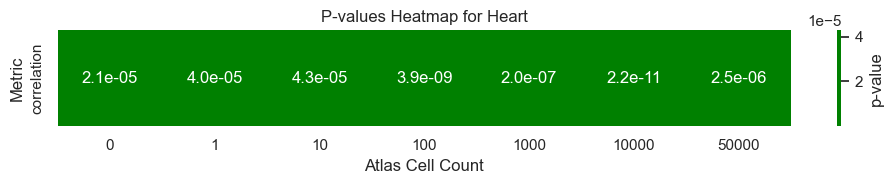

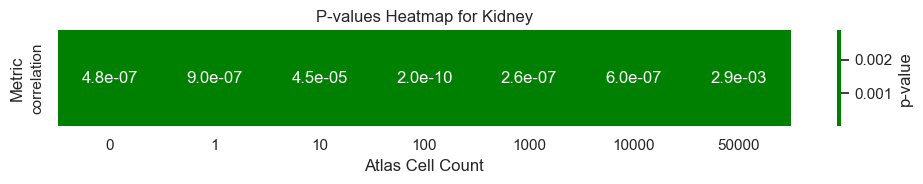

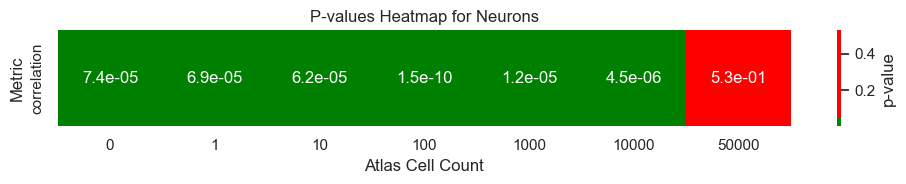

In [114]:

# plot heatmap of p-values for each dataset, where x axis is Atlas_cell_count, y axis is metric, and color is green if p-value < 0.05 else red
import seaborn as sns
import matplotlib.pyplot as plt
results_df = results_df[results_df['metric'].isin(['correlation'])]
for dataset in results_df['dataset'].unique():
    pivot_df = results_df[results_df['dataset'] == dataset].pivot(index='metric', columns='Atlas_cell_count', values='p_value')
    plt.figure(figsize=(10, 2))
    sns.heatmap(pivot_df, annot=True, fmt=".1e", cmap=sns.color_palette(["green", "red"]), center=0.05, cbar_kws={'label': 'p-value'})
    plt.title(f'P-values Heatmap for {dataset}')
    plt.xlabel('Atlas Cell Count')
    plt.ylabel('Metric')
    plt.axhline(y=-0.5, color='black', linewidth=2)  # Horizontal line at the top
    plt.axvline(x=-0.5, color='black', linewidth=2)  # Vertical line at the left
    plt.tight_layout()
    plt.show()


In [115]:
# convert class_balancing to Class balancing and geometric_sketching to Geometric sketching
df['Balancing_method'] = df['Balancing_method'].apply(lambda x: 'Class balancing' if x == 'class_balancing' else x)
df['Balancing_method'] = df['Balancing_method'].apply(lambda x: 'Geometric sketching' if x == 'geometric_sketching' else x)


In [116]:
df

,dataset,metric,value,ARtype,Atlas_cell_count,seed,Balancing_method
0,Heart,correlation,0.444208,AR,1000,46,Original combination
1,Heart,r2,0.206483,AR,1000,46,Original combination
2,Kidney,correlation,0.459010,AR,1000,46,Original combination
3,Kidney,r2,0.218427,AR,1000,46,Original combination
4,Neurons,correlation,0.779582,AR,1000,46,Original combination
...,...,...,...,...,...,...,...
415,Heart,r2,0.185977,Standard,100,46,Class balancing
416,Kidney,correlation,0.397724,Standard,100,46,Class balancing
417,Kidney,r2,0.166854,Standard,100,46,Class balancing
418,Neurons,correlation,0.804603,Standard,100,46,Class balancing


/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/4193958682.py:53: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


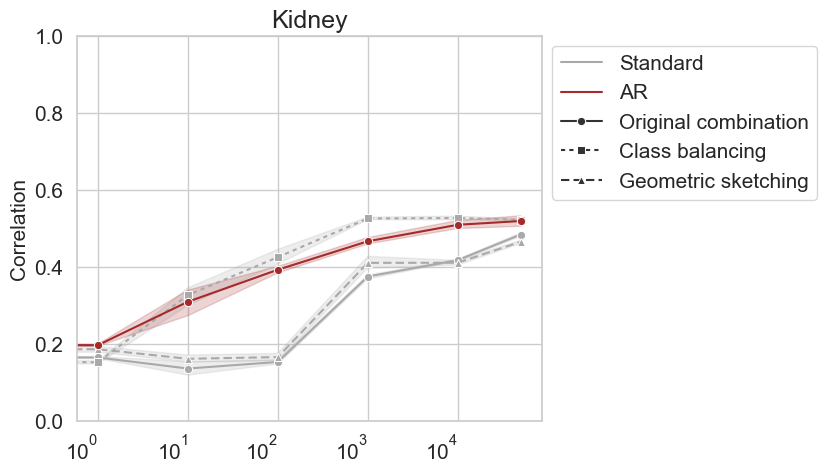

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/4193958682.py:53: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


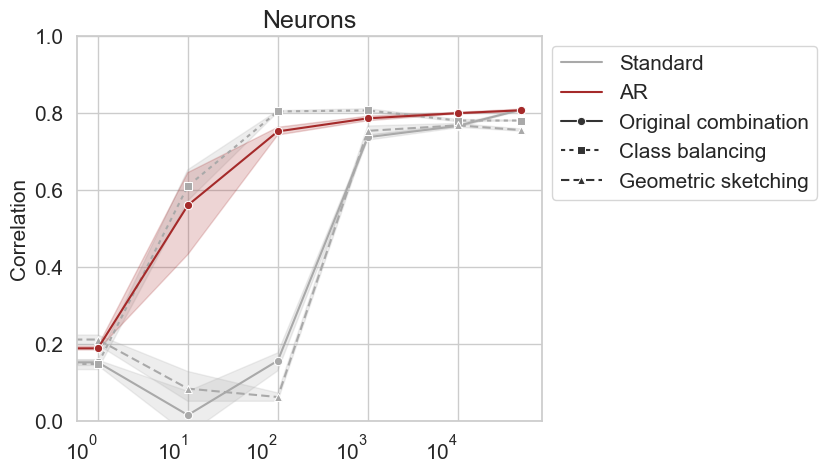

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_6052/4193958682.py:53: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


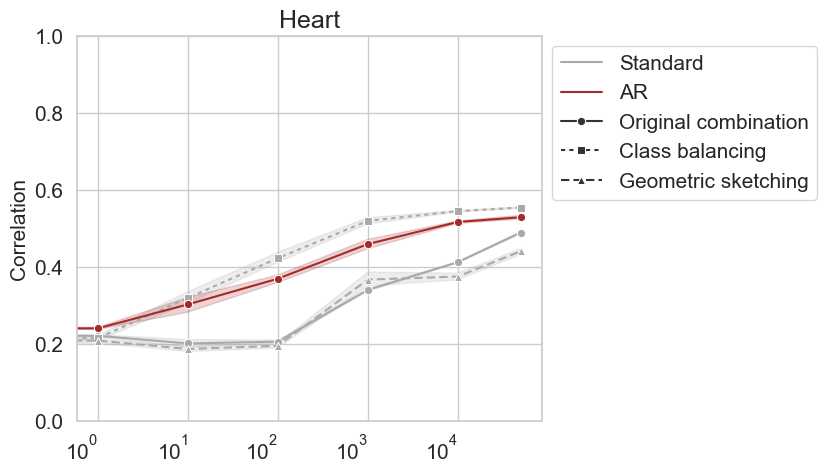

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

# plot group barplot with Atlas_cell_count in x-axis, value in y-axis, hue=ARtype
# convert Atlas_cell_count to log scale

# convert the Atlas_cell_count label into int format
df['Atlas_cell_count'] = df['Atlas_cell_count'].astype(int)
# sort based on Atlas_cell_count
df = df.sort_values(by='Atlas_cell_count')

# plot a group barplot for each dataset with metric in x-axis and value in y-axis, hue=AR_Type
palette = {'Standard':"darkgray",
           'AR':"brown"}

balancing_order = [
    'Original combination',
    'Class balancing',
    'Geometric sketching'
]

markers = {
    'Original combination': 'o',
    'Class balancing': 's',
    'Geometric sketching': '^'
}

dashes = {
    'Original combination': '',
    'Class balancing': (2, 2),
    'Geometric sketching': (4, 2)
}

for dataset in df['dataset'].unique():
    # loop through each metric
    for i, metric in enumerate(['correlation']):
        fig, axs = plt.subplots(1, 1, figsize=(6, 5))
        sns.set_theme(style="whitegrid")
        # Use hue to differentiate ARtype and style to differentiate alpha values with different colors and line styles
        g = sns.lineplot(
            data=df[(df['dataset'] == dataset) & (df['metric'] == metric)],
            x="Atlas_cell_count",
            y="value",
            hue="ARtype",
            style="Balancing_method",
            hue_order=['Standard', 'AR'],
            style_order=balancing_order,      # ✅ fixes assignment order
            markers=markers,                  # ✅ fixes marker shape
            dashes=dashes,                    # ✅ fixes line style
            palette=palette
        )
        # set x and y labels
        g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')
        g.set_xlabel('')
        g.set_ylabel(metric.capitalize(), fontsize=15)
        g.set_title(dataset.capitalize(), fontsize=18)
        g.tick_params(axis='both', which='major', labelsize=15)
        g.tick_params(axis='both', which='minor', labelsize=15)
        g.set_xscale("log", base=10)
        g.legend(loc='upper left', fontsize=15, bbox_to_anchor=(1, 1))
        # sort the legend in Balancing_method order: Original combination, class_balancing, geometric_sketching
        # sort the legend in Balancing_method order
        desired_order = [
            'Original combination',
            'Class balancing',
            'Geometric sketching'
        ]

        handles, labels = g.get_legend_handles_labels()

        # keep non-style entries (e.g., ARtype) in place
        ordered_handles = []
        ordered_labels = []

        # first add ARtype entries
        for h, l in zip(handles, labels):
            if l in ['Standard', 'AR']:
                ordered_handles.append(h)
                ordered_labels.append(l)

        # then add Balancing_method entries in the desired order
        for method in desired_order:
            for h, l in zip(handles, labels):
                if l == method:
                    ordered_handles.append(h)
                    ordered_labels.append(l)

        g.legend(
            ordered_handles,
            ordered_labels,
            loc='upper left',
            fontsize=15,
            bbox_to_anchor=(1, 1)
        )
        g.set(ylim=(0,1))
        
        # save the plot with high resolution
        plt.savefig(f'/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/new_results/scvi/figure/balanced_data/{dataset}_{metric}.png', dpi=600,
                    bbox_inches='tight')
        plt.show()
        
        

Compute pvalues between AR and class balancing

In [118]:
# write a piece of code that for each dataset, metric and Atlas_cell_count, it calculated the p-value between AR and Naive using t-test
from scipy import stats
results_class_balancing = pd.DataFrame(columns=['dataset', 'metric', 'Atlas_cell_count', 'p_value', 'better_method'])

for dataset in df['dataset'].unique():
    for metric in ['correlation']:
        for atlas_cell_count in df['Atlas_cell_count'].unique():
            ar_values = df[(df['dataset'] == dataset) & 
                                (df['metric'] == metric) & 
                                (df['Atlas_cell_count'] == atlas_cell_count) & 
                                (df['ARtype'] == 'AR') &
                                (df['Balancing_method'] == 'Original combination')]['value']
            naive_values = df[(df['dataset'] == dataset) & 
                                   (df['metric'] == metric) & 
                                   (df['Atlas_cell_count'] == atlas_cell_count) & 
                                   (df['ARtype'] == 'Standard') &
                                   (df['Balancing_method'] == 'Class balancing')]['value']
            better_method = 'Class balancing'
            if ar_values.mean() > naive_values.mean():
                better_method = 'AR'
            if len(ar_values) > 1 and len(naive_values) > 1:
                t_stat, p_value = stats.ttest_ind(ar_values, naive_values)
                results_class_balancing.loc[len(results_class_balancing)] = [dataset, metric, atlas_cell_count, p_value, better_method]
            else:
                results_class_balancing.loc[len(results_class_balancing)] = [dataset, metric, atlas_cell_count, None, better_method]

In [119]:
results_class_balancing

,dataset,metric,Atlas_cell_count,p_value,better_method
0,Kidney,correlation,0,1.906129e-07,AR
1,Kidney,correlation,1,4.760675e-07,AR
2,Kidney,correlation,10,4.886470e-01,Class balancing
3,Kidney,correlation,100,2.711378e-02,Class balancing
4,Kidney,correlation,1000,3.729433e-06,Class balancing
5,Kidney,correlation,10000,3.395414e-02,Class balancing
6,Kidney,correlation,50000,6.891337e-01,Class balancing
7,Neurons,correlation,0,7.392087e-06,AR
8,Neurons,correlation,1,9.133246e-04,AR
9,Neurons,correlation,10,4.880590e-01,Class balancing


In [120]:
results_class_balancing

,dataset,metric,Atlas_cell_count,p_value,better_method
0,Kidney,correlation,0,1.906129e-07,AR
1,Kidney,correlation,1,4.760675e-07,AR
2,Kidney,correlation,10,4.886470e-01,Class balancing
3,Kidney,correlation,100,2.711378e-02,Class balancing
4,Kidney,correlation,1000,3.729433e-06,Class balancing
5,Kidney,correlation,10000,3.395414e-02,Class balancing
6,Kidney,correlation,50000,6.891337e-01,Class balancing
7,Neurons,correlation,0,7.392087e-06,AR
8,Neurons,correlation,1,9.133246e-04,AR
9,Neurons,correlation,10,4.880590e-01,Class balancing
